2025-04-12 11:44:42,053 - INFO - Loading CIFAR-10 dataset...
2025-04-12 11:44:50,031 - INFO - CIFAR-10 dataset loaded successfully.
2025-04-12 11:44:50,075 - INFO - Testing: LR=0.001, Hidden1=256, Hidden2=128, L2_lambda=0.01
2025-04-12 11:45:03,457 - INFO - Epoch 1/10, LR: 0.001000, Train Loss: 6.1118, Train Acc: 0.2333, Val Loss: 6.1136, Val Acc: 0.2350
2025-04-12 11:45:04,385 - INFO - Saved best model with Val Acc: 0.2350
2025-04-12 11:45:17,591 - INFO - Epoch 2/10, LR: 0.001000, Train Loss: 5.9588, Train Acc: 0.2864, Val Loss: 5.9644, Val Acc: 0.2854
2025-04-12 11:45:18,486 - INFO - Saved best model with Val Acc: 0.2854
2025-04-12 11:45:31,718 - INFO - Epoch 3/10, LR: 0.001000, Train Loss: 5.8683, Train Acc: 0.3151, Val Loss: 5.8781, Val Acc: 0.3172
2025-04-12 11:45:32,637 - INFO - Saved best model with Val Acc: 0.3172
2025-04-12 11:45:45,970 - INFO - Epoch 4/10, LR: 0.001000, Train Loss: 5.8066, Train Acc: 0.3353, Val Loss: 5.8201, Val Acc: 0.3340
2025-04-12 11:45:46,907 - INFO - S

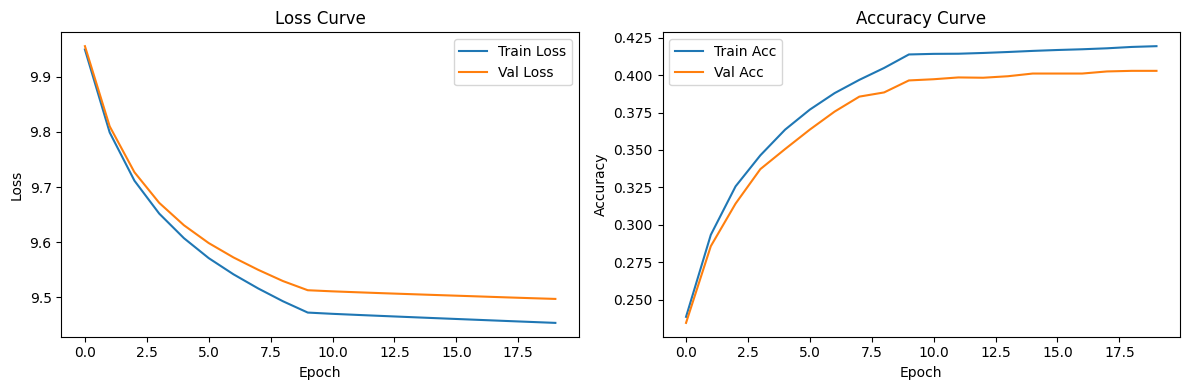

In [1]:
# main.py
from tools import *
import matplotlib.pyplot as plt
import logging

# 获取 logger（已经在 tools.py 中配置）
logger = logging.getLogger(__name__)

if __name__ == "__main__":
    # 加载数据
    logger.info("Starting the training process...")
    X_train, y_train, X_val, y_val, X_test, y_test, X_train_raw, X_val_raw, X_test_raw, mean, std, label_names = load_cifar10_torch()

    # 超参数搜索
    logger.info("Starting hyperparameter search...")
    results = hyperparameter_search(X_train, y_train, X_val, y_val, X_test, y_test)

    # 记录超参数搜索结果
    logger.info("Hyperparameter Search Results:")
    for result in results:
        logger.info(f"LR: {result['learning_rate']}, Hidden1: {result['hidden1_size']}, Hidden2: {result['hidden2_size']}, L2_lambda: {result['l2_lambda']}, Val Acc: {result['val_acc']:.4f}, Test Acc: {result['test_acc']:.4f}")

    # 找到最佳超参数
    best_result = max(results, key=lambda x: x['val_acc'])
    logger.info("Best Hyperparameters:")
    logger.info(f"LR: {best_result['learning_rate']}, Hidden1: {best_result['hidden1_size']}, Hidden2: {best_result['hidden2_size']}, L2_lambda: {best_result['l2_lambda']}, Val Acc: {best_result['val_acc']:.4f}, Test Acc: {best_result['test_acc']:.4f}")

    # 使用最佳超参数重新训练并测试
    best_lr = best_result['learning_rate']
    best_h1_size = best_result['hidden1_size']
    best_h2_size = best_result['hidden2_size']
    best_l2_lambda = best_result['l2_lambda']
    best_save_path = f'model_lr{best_lr}_h1{best_h1_size}_h2{best_h2_size}_l2{best_l2_lambda}.json'

    model = ThreeLayerNN(hidden1_size=best_h1_size, hidden2_size=best_h2_size, activation='relu')
    history = train(model, X_train, y_train, X_val, y_val, epochs=20, batch_size=64, learning_rate=best_lr, l2_lambda=best_l2_lambda, save_path=best_save_path)
    test_acc = evaluate(model, X_test, y_test, weights_path=best_save_path)

    # 绘制训练曲线
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Curve')
    plt.tight_layout()
    plt.show()
    logger.info("Training process completed.")

2025-04-14 13:52:09,393 - INFO - Loading CIFAR-10 dataset...
2025-04-14 13:52:18,604 - INFO - CIFAR-10 dataset loaded successfully.
2025-04-14 13:56:17,503 - INFO - Epoch 1/50, LR: 0.000100, Train Loss: 152.4278, Train Acc: 0.4306, Val Loss: 152.4296, Val Acc: 0.4282
2025-04-14 13:56:26,703 - INFO - Saved best model with Val Acc: 0.4282
2025-04-14 14:00:25,405 - INFO - Epoch 2/50, LR: 0.000100, Train Loss: 147.1640, Train Acc: 0.4565, Val Loss: 147.1676, Val Acc: 0.4448
2025-04-14 14:00:34,638 - INFO - Saved best model with Val Acc: 0.4448
2025-04-14 14:04:33,104 - INFO - Epoch 3/50, LR: 0.000100, Train Loss: 140.8399, Train Acc: 0.4671, Val Loss: 140.8465, Val Acc: 0.4572
2025-04-14 14:04:42,430 - INFO - Saved best model with Val Acc: 0.4572
2025-04-14 14:08:41,033 - INFO - Epoch 4/50, LR: 0.000100, Train Loss: 133.6992, Train Acc: 0.4870, Val Loss: 133.7080, Val Acc: 0.4656
2025-04-14 14:08:50,221 - INFO - Saved best model with Val Acc: 0.4656
2025-04-14 14:15:23,166 - INFO - Epoch 5

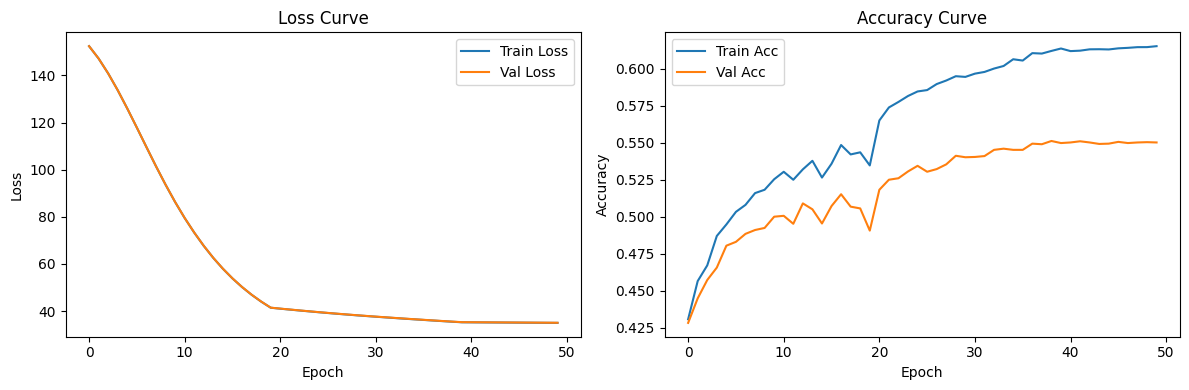

In [ ]:
# main.py
from tools import *
import matplotlib.pyplot as plt
import logging

# 获取 logger（已经在 tools.py 中配置）
logger = logging.getLogger(__name__)

if __name__ == "__main__":
    # # 加载数据
    logger.info("Starting the training process...")
    X_train, y_train, X_val, y_val, X_test, y_test, X_train_raw, X_val_raw, X_test_raw, mean, std, label_names = load_cifar10_torch()

    # 超参数搜索
    logger.info("Starting hyperparameter search...")
    results = hyperparameter_search(X_train, y_train, X_val, y_val, X_test, y_test, X_train_raw, X_val_raw)
    # 记录超参数搜索结果
    logger.info("Hyperparameter Search Results:")
    for result in results:
        logger.info(f"LR: {result['learning_rate']}, Hidden1: {result['hidden1_size']}, Hidden2: {result['hidden2_size']}, L2_lambda: {result['l2_lambda']}, Val Acc: {result['val_acc']:.4f}, Test Acc: {result['test_acc']:.4f}")

    # 找到最佳超参数
    best_result = max(results, key=lambda x: x['val_acc'])
    logger.info("Best Hyperparameters:")
    logger.info(f"LR: {best_result['learning_rate']}, Hidden1: {best_result['hidden1_size']}, Hidden2: {best_result['hidden2_size']}, L2_lambda: {best_result['l2_lambda']}, Val Acc: {best_result['val_acc']:.4f}, Test Acc: {best_result['test_acc']:.4f}")

    # 使用最佳超参数重新训练并测试
    best_lr = best_result['learning_rate']
    best_h1_size = best_result['hidden1_size']
    best_h2_size = best_result['hidden2_size']
    best_l2_lambda = best_result['l2_lambda']
    best_save_path = f'model_lr{best_lr}_h1{best_h1_size}_h2{best_h2_size}_l2{best_l2_lambda}.json'

    model = ThreeLayerNN(hidden1_size=best_h1_size, hidden2_size=best_h2_size)
    history = train(model, X_train, y_train, X_val, y_val, X_train_raw, epochs=50, batch_size=64, learning_rate=best_lr, l2_lambda=best_l2_lambda, save_path=best_save_path)
    test_acc = evaluate(model, X_test, y_test, weights_path=best_save_path)
    # 绘制训练曲线
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy Curve')
    plt.tight_layout()
    plt.show()
    logger.info("Training process completed.")